<a href="https://colab.research.google.com/github/Issam-Allymis/Superstore-sales-analysis/blob/master/superstore-regional-profitability-analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer & Sales Beahviour Analysis
## Objective
To analyse sales data to understand key drivers of revenue, profitability, and the impact of discounts across customers, regions and product category.

In [30]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import os
path = kagglehub.dataset_download("vivek468/superstore-dataset-final")
print(os.listdir(path))
df = pd.read_csv(path + "/Sample - Superstore.csv", encoding='latin1')
df.head(10)

Using Colab cache for faster access to the 'superstore-dataset-final' dataset.
['Sample - Superstore.csv']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
5,6,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
6,7,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.2800,4,0.00,1.9656
7,8,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520,6,0.20,90.7152
8,9,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.5040,3,0.20,5.7825
9,10,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.9000,5,0.00,34.4700


## Data Overview
The dataset contains information on:
- Sales
- Profit
- Discount
- Customer Names
- Product Categories

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [43]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [31]:
top_customers = df.groupby('Customer Name')['Sales'].sum()
top_customers.sort_values(ascending=False).head()

,Sales
Customer Name,
Sean Miller,25043.050
Tamara Chand,19052.218
Raymond Buch,15117.339
Tom Ashbrook,14595.620
Adrian Barton,14473.571


<Axes: xlabel='Customer Name'>

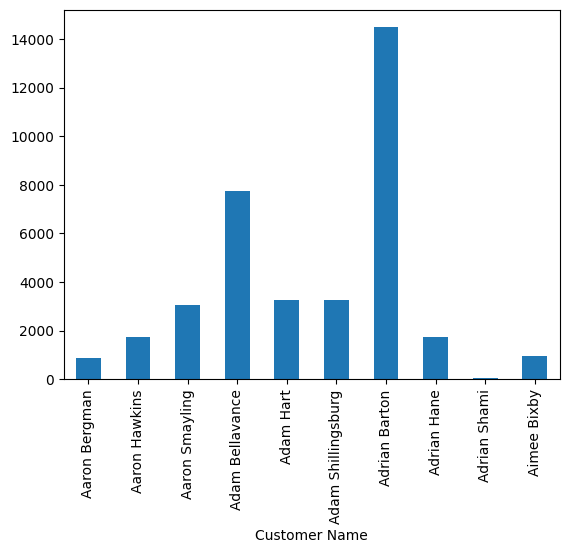

In [32]:
top_customers.head(10).plot(kind='bar')

## Insight
Revenue is highly concentrated among a small number of top customers rather than being evenly distributed across the customer base. This indicates that a significant portion of sales is dependent on key customers.
This creates a potential business risk, as losing a few high value customers could negatively impact the business revenue overall.

In [33]:
discount = df.groupby('Customer Name')['Discount'].mean()

In [35]:
cust_analysis = pd.concat([top_customers, discount], axis=1)
cust_analysis.head(10)

,Sales,Discount
Customer Name,,
Aaron Bergman,886.156,0.066667
Aaron Hawkins,1744.700,0.090909
Aaron Smayling,3050.692,0.355000
Adam Bellavance,7755.620,0.044444
Adam Hart,3250.337,0.135000
Adam Shillingsburg,3255.310,0.180000
Adrian Barton,14473.571,0.240000
Adrian Hane,1735.514,0.237500
Adrian Shami,58.820,0.066667


In [37]:
customer_analysis = df.groupby('Customer Name').agg({
    'Sales': 'sum',
    'Discount': 'mean',
    'Profit': 'sum'
})
customer_analysis.head(10)

,Sales,Discount,Profit
Customer Name,,,
Aaron Bergman,886.156,0.066667,129.3465
Aaron Hawkins,1744.700,0.090909,365.2152
Aaron Smayling,3050.692,0.355000,-253.5746
Adam Bellavance,7755.620,0.044444,2054.5885
Adam Hart,3250.337,0.135000,281.1890
Adam Shillingsburg,3255.310,0.180000,64.5374
Adrian Barton,14473.571,0.240000,5444.8055
Adrian Hane,1735.514,0.237500,-2.3146
Adrian Shami,58.820,0.066667,21.8496


## Insight
There is no clear relationship between higher discounts and increase customer revenue. Some hgih value customers reveive higher discounts while still generating strong sales.
However, further analysis shows that higher discounts significantly reduce profitability. This suggests that while discounts may be used strategically to drive sales, the can negatively impact overall profit if not carefully managed.

In [39]:
df.groupby('Region')[['Sales', 'Profit']].sum()

,Sales,Profit
Region,,
Central,501239.8908,39706.3625
East,678781.2400,91522.7800
South,391721.9050,46749.4303
West,725457.8245,108418.4489


In [40]:
df.groupby('Region')[['Sales', 'Profit', 'Discount']].mean()

,Sales,Profit,Discount
Region,,,
Central,215.772661,17.092709,0.240353
East,238.336110,32.135808,0.145365
South,241.803645,28.857673,0.147253
West,226.493233,33.849032,0.109335


## Insight
The west region generates the highest sales and profit, supported by relatively lower discounts.
In contrast, the Central region shows moderate sales but significantly lower profitability. This is accompanied by the higher average discount among all regions.
This is suggesting that higher discounting in the central region is likely reducing profitability, making it a key area for improvement.

In [41]:
df[df['Region'] == 'Central'].groupby('Category')[['Sales', 'Profit']].sum()

,Sales,Profit
Category,,
Furniture,163797.1638,-2871.0494
Office Supplies,167026.4150,8879.9799
Technology,170416.3120,33697.4320


## Insight
Further analysis of the Central region shows that the furniture category is the main driver of low profitability . While it generates a reasonable amount of sales, it produces negative profits, unlike Office Supplies and Technology which remain profitable.
This indicated that losses in the Central region are primarily driven by poor perfomance in the furniture category rather than the region a whole.

## Final Conclusion
The analysis shows that while the business generates strong sales overall, profitability is significantly affected by discounting strategies.
Furniture, particularly in the central region, is the main contributor to profit losses. High discounts are strongly linked to reduced profit, even when sales remain high. Improving discount control and focusing on profitable categories could significantly enhance overall performance.